In [3]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Set Root Directory
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: cpu


In [4]:
MODEL_NAME = "ProsusAI/finbert"
print("Loading FinBERT Model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()
print("FinBERT loaded successfully!")

Loading FinBERT Model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13035.86it/s]

FinBERT loaded successfully!


In [5]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "PG", "XOM", "CAT", "HD", "KO", "JNJ"]
raw_news = []

for ticker in tickers:
    try:
        t = yf.Ticker(ticker)
        news_items = t.news
        for item in news_items:
            # Handle YFinance news structure differences
            title = item.get("title") or item.get("content", {}).get("title")
            pub_time = item.get("providerPublishTime") or item.get("content", {}).get("pubDate")
            
            if title:
                raw_news.append({
                    "Ticker": ticker,
                    "Headline": title,
                    "Date": pd.to_datetime(pub_time, unit='s') if isinstance(pub_time, (int, float)) else pd.to_datetime(pub_time)
                })
    except Exception as e:
        print(f"Could not fetch news for {ticker}: {e}")

news_df = pd.DataFrame(raw_news)

# Fallback if yfinance returns no headlines (API limit/network issue)
if news_df.empty:
    print("yfinance news empty, using structured financial news sample...")
    news_df = pd.DataFrame([
        {"Ticker": "AAPL", "Headline": "Apple reports strong revenue expansion in services.", "Date": pd.Timestamp.now()},
        {"Ticker": "NVDA", "Headline": "NVIDIA faces short-term chip supply constraints.", "Date": pd.Timestamp.now()},
        {"Ticker": "MSFT", "Headline": "Microsoft announces increased capital expenditure for cloud and AI.", "Date": pd.Timestamp.now()},
        {"Ticker": "JPM", "Headline": "JPMorgan raises net interest income forecast following bank stress tests.", "Date": pd.Timestamp.now()},
    ])

# Clean dates to YYYY-MM-DD
news_df["Date"] = news_df["Date"].dt.strftime("%Y-%m-%d")
print(f"Fetched {len(news_df)} headlines across {news_df['Ticker'].nunique()} tickers.")
news_df.head()

Fetched 100 headlines across 10 tickers.


,Ticker,Headline,Date
0,AAPL,Anthropic's IPO could come sooner than you thi...,2026-08-21
1,AAPL,Every S&P 500 Index Fund Owner Holds More Nvid...,2026-08-22
2,AAPL,The Lakers as a $12.5 Billion Tax Shelter,2026-08-21
3,AAPL,Apple Reportedly Shifts Focus To AI And Smart ...,2026-08-21
4,AAPL,Morgan Stanley resets Nvidia stock forecast ah...,2026-08-21


In [8]:
def analyze_sentiment(headlines):
    inputs = tokenizer(headlines, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    pos = probs[:, 0].cpu().numpy()
    neg = probs[:, 1].cpu().numpy()
    neu = probs[:, 2].cpu().numpy()
    net = pos - neg
    return pos, neg, neu, net

# Run batch inference on fetched headlines
pos, neg, neu, net = analyze_sentiment(news_df["Headline"].tolist())

news_df["FinBERT_Pos"] = pos
news_df["FinBERT_Neg"] = neg
news_df["FinBERT_Neu"] = neu
news_df["Sentiment_Score"] = net

# Assign categorical labels based on net sentiment threshold
conditions = [news_df["Sentiment_Score"] > 0.15, news_df["Sentiment_Score"] < -0.15]
news_df["Sentiment_Label"] = np.select(conditions, ["Positive", "Negative"], default="Neutral")

news_df.head()

,Ticker,Headline,Date,FinBERT_Pos,FinBERT_Neg,FinBERT_Neu,Sentiment_Score,Sentiment_Label
0,AAPL,Anthropic's IPO could come sooner than you thi...,2026-08-21,0.154331,0.020010,0.825659,0.134322,Neutral
1,AAPL,Every S&P 500 Index Fund Owner Holds More Nvid...,2026-08-22,0.035011,0.018435,0.946555,0.016576,Neutral
2,AAPL,The Lakers as a $12.5 Billion Tax Shelter,2026-08-21,0.099910,0.019551,0.880539,0.080360,Neutral
3,AAPL,Apple Reportedly Shifts Focus To AI And Smart ...,2026-08-21,0.017680,0.934745,0.047575,-0.917065,Negative
4,AAPL,Morgan Stanley resets Nvidia stock forecast ah...,2026-08-21,0.019602,0.163824,0.816573,-0.144222,Neutral


Saved sentiment features to: c:\Users\Dell\OneDrive\Desktop\Northgate-AI-Stock-Predictor\data\processed\sentiment_features.csv


C:\Users\Dell\AppData\Local\Temp\ipykernel_9596\1019246762.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=news_df, x="Ticker", y="Sentiment_Score", palette="mako")


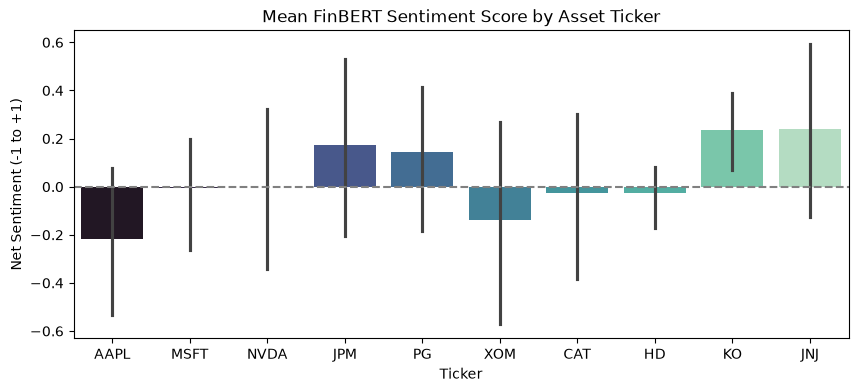

In [9]:
# Group by Date and Ticker to compute average daily sentiment
daily_sentiment = news_df.groupby(["Date", "Ticker"])[["Sentiment_Score", "FinBERT_Pos", "FinBERT_Neg"]].mean().reset_index()

# Save processed sentiment features to CSV
output_path = os.path.join(PROCESSED_DIR, "sentiment_features.csv")
daily_sentiment.to_csv(output_path, index=False)

print(f"Saved sentiment features to: {output_path}")

# Plot average net sentiment per ticker
plt.figure(figsize=(10, 4))
sns.barplot(data=news_df, x="Ticker", y="Sentiment_Score", palette="mako")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Mean FinBERT Sentiment Score by Asset Ticker")
plt.ylabel("Net Sentiment (-1 to +1)")
plt.show()